In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


Nome: Amanda Barreto Lima
Periodo: 6
Turma: A


**Objetivo: este notebook tem como objetivo reavaliar o clássico dataset Iris, mas utilizandoos dados obtidos diretamente do Kaggle (e não a função `load_iris()` doscikit-learn).**


**1. Carregamento dos dados**

Os dados são carregados diretamente do arquivo CSV disponibilizado pelo dataset
do Kaggle, anexado automaticamente ao ambiente em `/kaggle/input/`.

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score, f1_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [3]:
# Confirma o dataset anexado e o caminho
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


In [4]:
#Esse código lê o arquivo Iris.csv e salva os dados em um DataFrame chamado df, depois mostra as 5 primeiras linhas

caminho_csv = "/kaggle/input/datasets/menegidio/iris-species/Iris.csv"

df = pd.read_csv(caminho_csv)
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


**2. Inspeção inicial dos dados**

Antes de qualquer análise, verifiquei a estrutura do dataset: número de
linhas/colunas, tipos de dados, valores ausentes e estatísticas descritivas.

In [5]:
print("Dimensões do dataset:", df.shape)
df.info()

Dimensões do dataset: (150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
#remove coluna de indicie, se existir
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
#esse código verifica quantos valores ausentes (NaN) existem em cada coluna e quantas linhas duplicadas existem no DataFrame df.

print("Valores ausentes por coluna:")
print(df.isnull().sum())

print("\nValores duplicados:", df.duplicated().sum())

Valores ausentes por coluna:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Valores duplicados: 3


In [8]:
#esse código identifica automaticamente a coluna Species como alvo e depois conta quantos exemplos existem de cada espécie de íris.

col_alvo = [c for c in df.columns if c.lower() == "species"][0]
print("Coluna alvo identificada:", col_alvo)

df[col_alvo].value_counts()

Coluna alvo identificada: Species


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

**3. Análise Exploratória de Dados (EDA)**

Nesta seção investiguei a distribuição das variáveis numéricas e as correlações entre as features, para entender quais
atributos mais contribuem para a distinção entre as espécies de Iris.

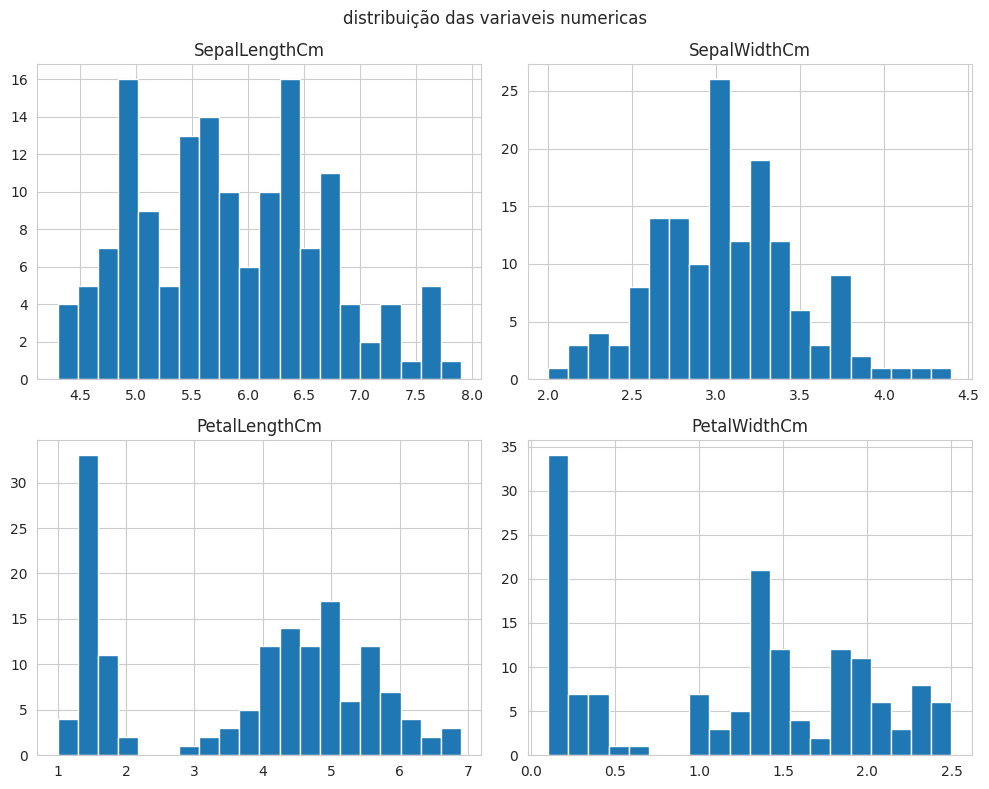

In [9]:
#esse código seleciona as colunas numéricas e cria histogramas para visualizar a distribuição dos valores de cada variável.

features_num = df.select_dtypes(include=[np.number]).columns.tolist()

df[features_num].hist(bins=20, figsize=(10, 8))
plt.suptitle("distribuição das variaveis numericas")
plt.tight_layout()
plt.show()

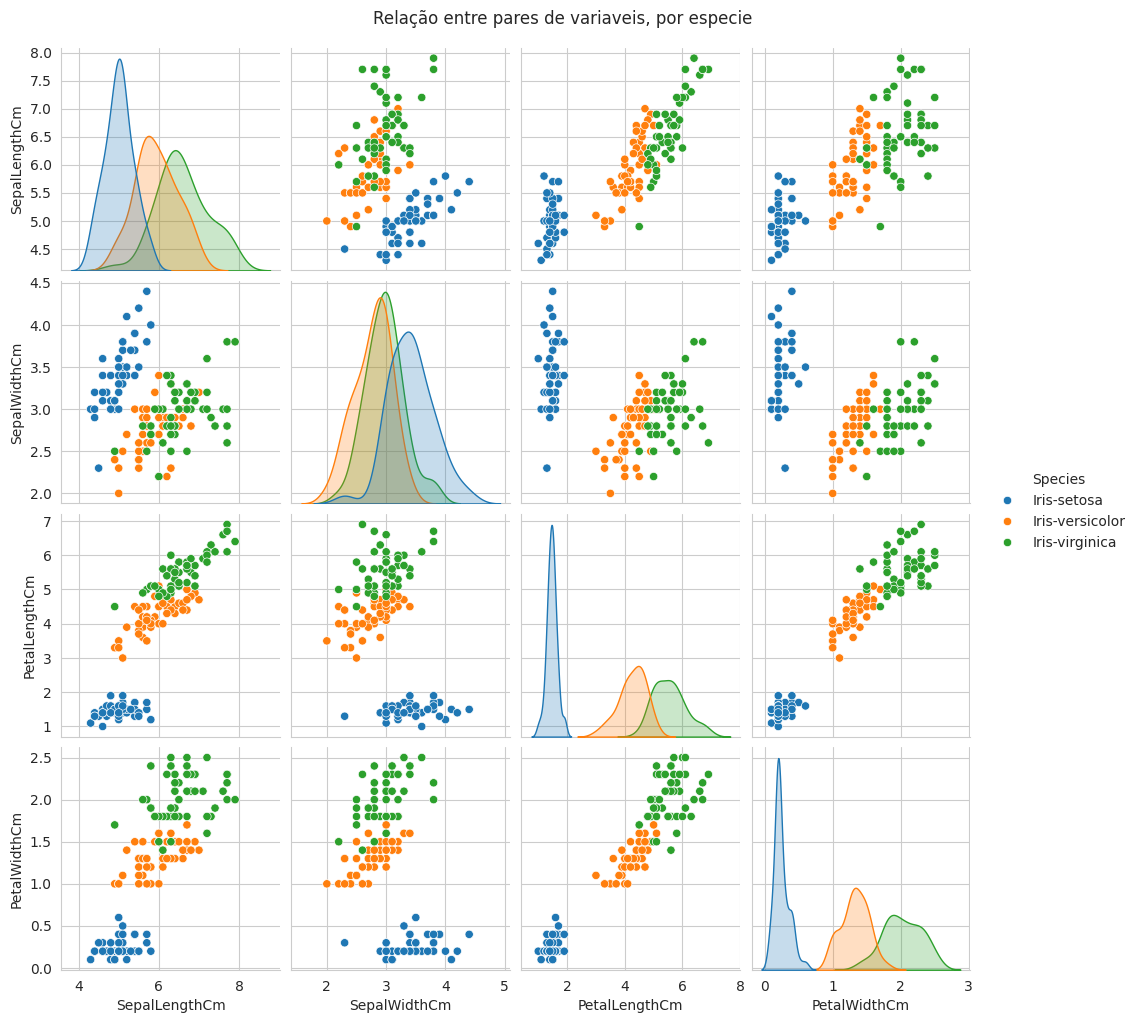

In [10]:
#esse código cria gráficos de dispersão entre todas as variáveis, usando cores diferentes para cada espécie, para visualizar as relações e a separação entre as classes.

sns.pairplot(df, hue=col_alvo, diag_kind="kde")
plt.suptitle("Relação entre pares de variaveis, por especie", y=1.02)
plt.show()

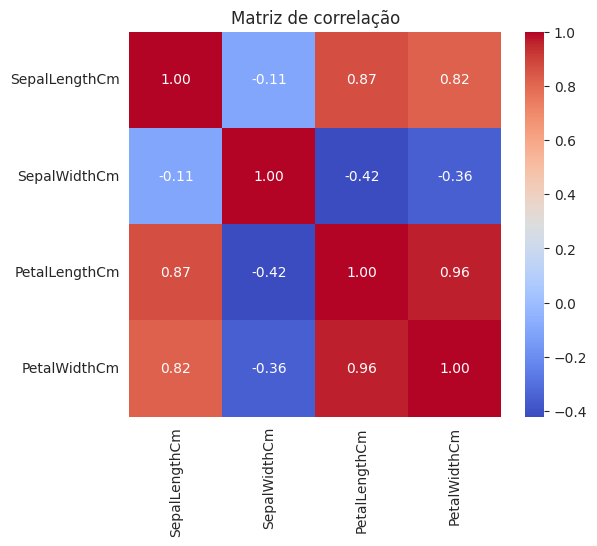

In [11]:
# Matriz de correlação entre as features numéricas
plt.figure(figsize=(6, 5))
sns.heatmap(df[features_num].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlação")
plt.show()

**Observações**

- O dataset está balanceado entre as três classes (Setosa, Versicolor,
  Virginica).
  
- Não há valores ausentes nem duplicados relevantes a tratar (As 3 linhas duplicadas surgem após a remoção da coluna Id. Como as medidas são arredondadas em 0,1 cm, flores distintas podem apresentar exatamente os
mesmos valores nas quatro features.)


- PetalLengthCm e PetalWidthCm mostram forte correlação e são as
  variáveis com maior poder de separação visual entre as espécies.

  
- Iris-setosa é claramente separável das demais apenas com features de
  pétala; versicolor e virginica apresentam alguma sobreposição.

**4. Pré-processamento**

- Codificação da variável alvo (Species) em valores numéricos.
- Separação entre features (X) e alvo (y).
- Divisão em conjuntos de treino e teste (80/20, estratificada).
- Padronização das features (essencial para o SVM, que é sensível à escala).

In [12]:
## Cria o codificador que transforma categorias em números.
le = LabelEncoder()

## Converte os valores da coluna alvo em números e salva na coluna "target".
df["target"] = le.fit_transform(df[col_alvo])

# Seleciona as colunas numéricas que serão usadas para fazer a previsão.
X = df[features_num]

# Define a variável que o modelo deverá prever.
y = df["target"]

# Mostra quais categorias existem e qual número foi atribuído a cada uma.
print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))

Classes: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


In [13]:
# Divide os dados em treino (80%) e teste (20%).
# stratify=y mantém a proporção das classes nos dois grupos.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Cria um normalizador para deixar os valores das características em uma escala semelhante.
scaler = StandardScaler()

# Aprende a escala usando os dados de treino e normaliza o treino.
X_train_scaled = scaler.fit_transform(X_train)

# Normaliza os dados de teste usando a mesma escala do treino.
X_test_scaled = scaler.transform(X_test)

# Mostra a quantidade de linhas e colunas dos dados de treino e teste.
print("Treino:", X_train_scaled.shape, " Teste:", X_test_scaled.shape)

Treino: (120, 4)  Teste: (30, 4)


**5. Modelagem - Support Vector Machine (SVM)**

O modelo de classificação utilizado neste trabalho é o SVM implementado via sklearn.svm.SVC

Primeiro treinei um modelo baseline com kernel RBF e parâmetros padrão, e em seguida otimizei o hiperpârametro (C, gamma, kernel) via GridSearchCV com validação cruzada.

In [14]:
# Cria o modelo SVM usando o kernel RBF para identificar padrões não lineares.
svm_base = SVC(kernel="rbf", random_state=42)

# Treina o modelo utilizando os dados de treino.
svm_base.fit(X_train_scaled, y_train)

# Usa o modelo treinado para fazer previsões nos dados de teste.
y_pred_base = svm_base.predict(X_test_scaled)

# Calcula e mostra a acurácia, ou seja, a porcentagem de previsões corretas.
print("Acurácia (baseline):", accuracy_score(y_test, y_pred_base))

Acurácia (baseline): 0.9666666666666667


In [15]:
# Define os valores de hiperparâmetros que serão testados no SVM.
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.1, 1],
    "kernel": ["rbf", "linear", "poly"]
}

# Cria uma busca para testar todas as combinações de parâmetros.
grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid, #conjunto de configurações que o modelo vai experimentar.
    cv=5, #divide os dados em 5 partes para validação cruzada.
    scoring="accuracy", # usa a acurácia para escolher o melhor modelo.
    n_jobs=-1 #utiliza todos os processadores disponíveis.
)

# Treina e testa todas as combinações de hiperparâmetros.
grid_search.fit(X_train_scaled, y_train)

# Mostra a combinação de parâmetros que teve o melhor resultado.
print("Melhores hiperparâmetros:", grid_search.best_params_)

# Mostra a melhor acurácia obtida durante a validação cruzada.
print("Melhor acurácia (validação cruzada):", grid_search.best_score_)


Melhores hiperparâmetros: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Melhor acurácia (validação cruzada): 0.9833333333333332


In [16]:
# Pega o modelo SVM que apresentou o melhor resultado no GridSearchCV.
melhor_svm = grid_search.best_estimator_

# Usa o melhor modelo para fazer previsões com os dados de teste.
y_pred = melhor_svm.predict(X_test_scaled)

**6. Avaliação do modelo**

Avaliei o modelo final no conjunto de teste, usando as métricas clássicas de classificação: acurácia, precisão, recall, F1-score e matriz de confusão

In [17]:
# Calcula a acurácia: porcentagem de previsões que o modelo acertou.
acc = accuracy_score(y_test, y_pred)

# Calcula a precisão média entre todas as classes.
prec = precision_score(y_test, y_pred, average="macro")

# Calcula o recall médio, verificando quantos casos de cada classe foram identificados corretamente.
rec = recall_score(y_test, y_pred, average="macro")

# Calcula o F1-score médio, combinando precisão e recall.
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Acurácia: {acc: .4f}")
print(f"Precisão: {prec: .4f}")
print(f"Recall: {rec: .4f}")
print(f"F1-score: {f1: .4f}")

Acurácia:  0.9667
Precisão:  0.9697
Recall:  0.9667
F1-score:  0.9666


In [18]:
print("Relatorio de classificação: \n")

# Gera um relatório com as principais métricas do modelo:
# precisão, recall, F1-score e quantidade de exemplos de cada classe.
# target_names=le.classes_: mostra os nomes originais das classes em vez dos números.
print(classification_report(y_test, y_pred, target_names=le.classes_))

Relatorio de classificação: 

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



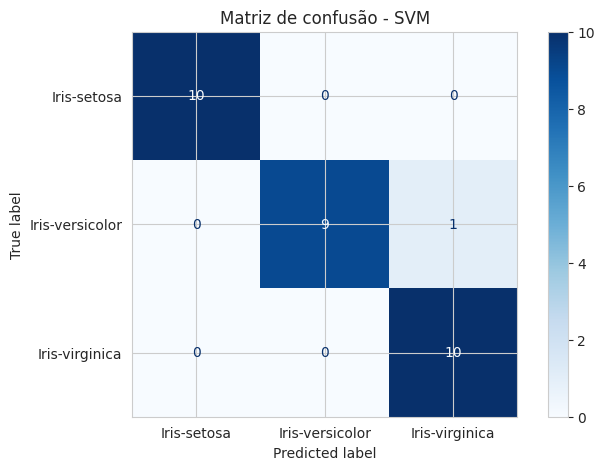

In [19]:
# Cria a matriz de confusão, comparando os valores reais com as previsões do modelo.
cm = confusion_matrix(y_test, y_pred)

# Prepara a matriz para ser exibida em um gráfico.
# display_labels mostra os nomes das classes.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# Desenha a matriz de confusão usando tons de azul.
disp.plot(cmap="Blues")

# Define o título do gráfico.
plt.title("Matriz de confusão - SVM")
plt.show()

In [20]:
# Faz validação cruzada dividindo os dados de treino em 5 partes (folds).
# O modelo é treinado e testado 5 vezes, usando uma parte diferente para teste em cada vez.
cv_scores = cross_val_score(melhor_svm, X_train_scaled, y_train, cv=5)

# Mostra a acurácia obtida em cada uma das 5 partes.
print("Acuracias por fold:", cv_scores)

# Mostra a média das acurácias e o desvio padrão.
# A média indica o desempenho geral do modelo.
# O desvio padrão indica o quanto os resultados variam entre os folds.
print("Media:", cv_scores.mean(), " desvio padrão: ", cv_scores.std())

Acuracias por fold: [0.91666667 1.         1.         1.         1.        ]
Media: 0.9833333333333332  desvio padrão:  0.03333333333333335


**7. Conclusão**

- O modelo SVM, após otimização de hiperparâmetros via GridSearchCV
  (kernel='rbf', C=1, gamma=0.1), alcançou 97% de acurácia no
  conjunto de teste (29 de 30 amostras corretas).
- A classe Iris-setosa foi classificada com 100% de precisão e recall,
  confirmando a separação quase perfeita já observada na EDA.
- O único erro do modelo foi 1 amostra de Iris-versicolor classificada
  como Iris-virginica (recall de versicolor = 0,90; precisão de
  virginica = 0,91). Não houve confusão envolvendo setosa.
- Esse resultado é consistente com a sobreposição entre versicolor e
  virginica observada nos boxplots e no pairplot da EDA, especialmente
  nas features de pétala.
- A validação cruzada de 5 folds confirmou a estabilidade do modelo
  (média = 0,9833, desvio padrão = 0,033), com apenas um fold apresentando
  desempenho ligeiramente inferior (0,9167), provavelmente por conter mais
  casos de fronteira entre versicolor e virginica.
- Em resumo, o SVM com kernel RBF se mostrou um classificador robusto para
  este dataset, com erro concentrado exatamente onde a separação entre
  classes é naturalmente mais difícil.
